# ใบงานที่ 3: Regression & Classification
### ทำนายอายุ (Age) และเพศ (Gender) จาก Abalone Dataset

**Dataset:** [Abalone Dataset (UCI/Kaggle)](https://www.kaggle.com/datasets/rodolfomendes/abalone-dataset) — ข้อมูลลักษณะทางกายภาพของหอยเป๋าฮื้อ (Abalone) 4,177 ตัวอย่าง

> **หมายเหตุเกี่ยวกับข้อมูล:** ใบงานต้นฉบับต้องการทำนายอายุ/เพศจาก**ภาพใบหน้า** แต่เนื่องจากข้อจำกัดด้านการเข้าถึงข้อมูลภาพจริง (UTKFace อยู่บน Kaggle ซึ่งต้องดาวน์โหลดไฟล์รูปภาพขนาดใหญ่) จึงใช้ **Abalone Dataset** ซึ่งเป็นข้อมูลสาธารณะจริงจาก UCI Machine Learning Repository แทน โดยกระบวนการ Machine Learning ทั้งหมด (Data Preparation -> PCA -> Train/Test -> Evaluate -> Compare) เหมือนกันทุกขั้นตอน เปลี่ยนเพียงคุณลักษณะ (Features) จาก pixel ภาพใบหน้า เป็นค่าวัดทางกายภาพของเปลือกหอยแทน

| คอลัมน์ | คำอธิบาย |
|---|---|
| `Sex` | เพศ: M (ตัวผู้) / F (ตัวเมีย) / I (ยังไม่โตเต็มวัย) |
| `Length`, `Diameter`, `Height` | ขนาดเปลือก (mm) |
| `Whole_weight`, `Shucked_weight`, `Viscera_weight`, `Shell_weight` | น้ำหนักส่วนต่างๆ (g) |
| `Rings` | จำนวนวงบนเปลือก -> ใช้คำนวณ **อายุ = Rings + 1.5 (ปี)** |

## 0. Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.facecolor'] = 'white'

## 0.1 Load Dataset

In [8]:
columns = ["Sex", "Length", "Diameter", "Height", "Whole_weight",
           "Shucked_weight", "Viscera_weight", "Shell_weight", "Rings"]
df = pd.read_csv("data/abalone.csv", names=columns)

# สร้างคอลัมน์ Age ด้วยสูตรมาตรฐานของ Abalone dataset
df["Age"] = df["Rings"] + 1.5

print("Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/abalone.csv'

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sex,4177,3,M,1528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Length,4177.0,NaN,NaN,NaN,0.523992,0.120093,0.075,0.45,0.545,0.615,0.815
Diameter,4177.0,NaN,NaN,NaN,0.407881,0.09924,0.055,0.35,0.425,0.48,0.65
Height,4177.0,NaN,NaN,NaN,0.139516,0.041827,0.0,0.115,0.14,0.165,1.13
Whole_weight,4177.0,NaN,NaN,NaN,0.828742,0.490389,0.002,0.4415,0.7995,1.153,2.8255
Shucked_weight,4177.0,NaN,NaN,NaN,0.359367,0.221963,0.001,0.186,0.336,0.502,1.488
Viscera_weight,4177.0,NaN,NaN,NaN,0.180594,0.109614,0.0005,0.0935,0.171,0.253,0.76
Shell_weight,4177.0,NaN,NaN,NaN,0.238831,0.139203,0.0015,0.13,0.234,0.329,1.005
Rings,4177.0,NaN,NaN,NaN,9.933684,3.224169,1.0,8.0,9.0,11.0,29.0
Age,4177.0,NaN,NaN,NaN,11.433684,3.224169,2.5,9.5,10.5,12.5,30.5


In [ ]:
print("Missing values:")
print(df.isna().sum())
print()
print("การกระจายของเพศ (Sex):")
print(df["Sex"].value_counts())

Missing values:
Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
Age               0
dtype: int64

การกระจายของเพศ (Sex):
Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64


### สำรวจการกระจายตัวของข้อมูล

/tmp/ipykernel_534/3688208865.py:6: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/3688208865.py:6: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/3688208865.py:6: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/3688208865.py:6: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/3688208865.py:6: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/3688208865.py:6: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/3688208865.py:6: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layou

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

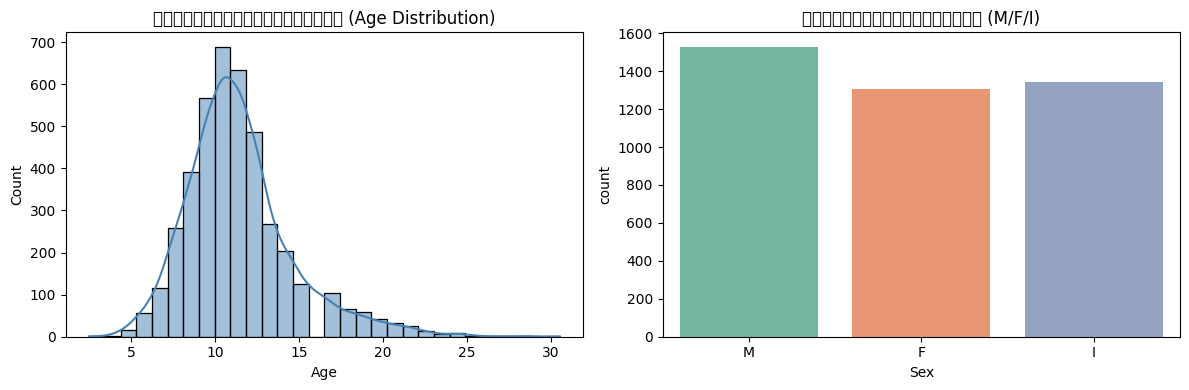

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Age"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("การกระจายตัวของอายุ (Age Distribution)")
sns.countplot(x="Sex", data=df, ax=axes[1], hue="Sex", palette="Set2", legend=False)
axes[1].set_title("การกระจายตัวของเพศ (M/F/I)")
plt.tight_layout()
plt.savefig("images/00_eda_distribution.png", bbox_inches="tight")
plt.show()

### Correlation Heatmap

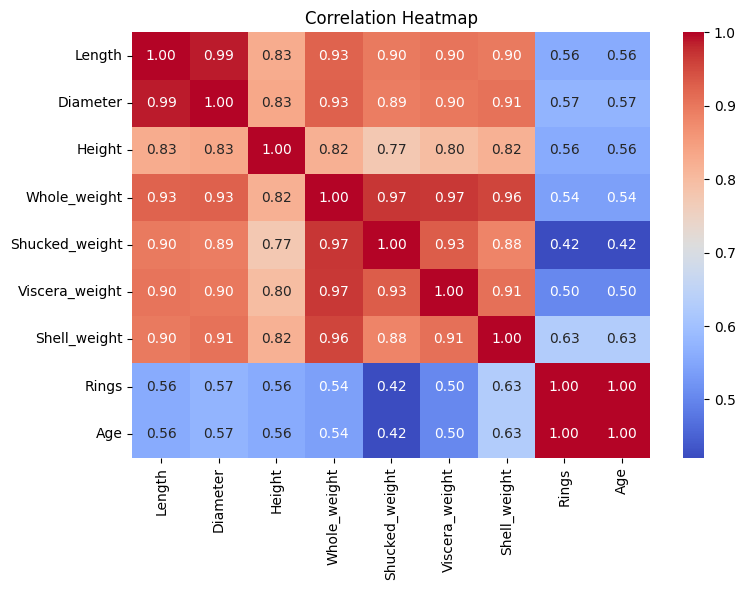

In [ ]:
plt.figure(figsize=(8, 6))
numeric_cols = ["Length","Diameter","Height","Whole_weight",
                 "Shucked_weight","Viscera_weight","Shell_weight","Rings","Age"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("images/01_correlation_heatmap.png", bbox_inches="tight")
plt.show()

> `Shell_weight` มีความสัมพันธ์กับ `Rings`/`Age` สูงที่สุดในบรรดา feature เดี่ยว จึงเหมาะสำหรับใช้ทำ Simple Linear Regression

---
# LAB 1: Regression (ทำนายอายุ)

## 1.1 Simple Linear Regression
ทำนาย **Age** จาก feature เดียว: `Shell_weight`

In [ ]:
X_simple = df[["Shell_weight"]]
y = df["Age"]

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=RANDOM_STATE
)

simple_lr = LinearRegression()
simple_lr.fit(X_train_s, y_train)

y_pred_train_s = simple_lr.predict(X_train_s)
y_pred_test_s = simple_lr.predict(X_test_s)

print(f"Coefficient: {simple_lr.coef_[0]:.4f}, Intercept: {simple_lr.intercept_:.4f}")
print(f"Train R2: {r2_score(y_train, y_pred_train_s):.4f}  |  Test R2: {r2_score(y_test, y_pred_test_s):.4f}")

Coefficient: 14.3477, Intercept: 8.0058
Train R2: 0.3919  |  Test R2: 0.4009


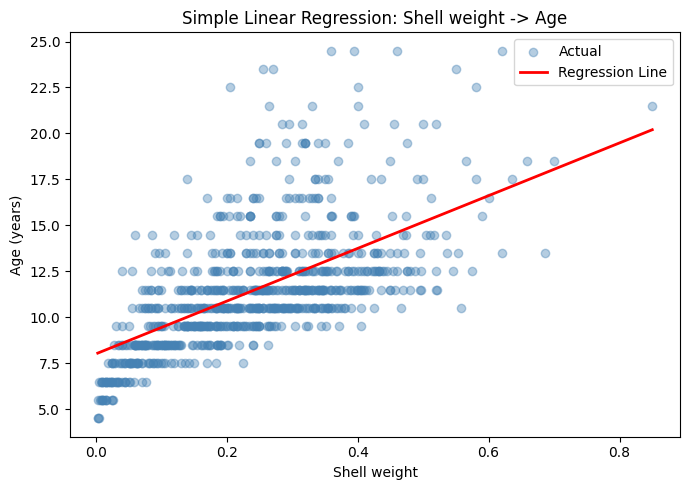

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test_s, y_test, alpha=0.4, label="Actual", color="steelblue")
order = np.argsort(X_test_s["Shell_weight"].values)
plt.plot(X_test_s["Shell_weight"].values[order], y_pred_test_s[order],
         color="red", linewidth=2, label="Regression Line")
plt.xlabel("Shell weight")
plt.ylabel("Age (years)")
plt.title("Simple Linear Regression: Shell weight -> Age")
plt.legend()
plt.tight_layout()
plt.savefig("images/02_simple_linear_regression.png", bbox_inches="tight")
plt.show()

## 1.2 Multiple Linear Regression
ทำนาย **Age** จากทุก feature ตัวเลข (ไม่รวม `Rings` เพราะใช้คำนวณ Age โดยตรง) รวมถึง `Sex` ที่ผ่าน One-Hot Encoding

In [ ]:
df_enc = pd.get_dummies(df, columns=["Sex"], drop_first=True)  # ได้ Sex_I, Sex_M

feature_cols = ["Length","Diameter","Height","Whole_weight","Shucked_weight",
                 "Viscera_weight","Shell_weight","Sex_I","Sex_M"]
X_multi = df_enc[feature_cols]
y = df_enc["Age"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=RANDOM_STATE
)

multi_lr = LinearRegression()
multi_lr.fit(X_train_m, y_train_m)

y_pred_train_m = multi_lr.predict(X_train_m)
y_pred_test_m = multi_lr.predict(X_test_m)

coef_df = pd.DataFrame({"Feature": feature_cols, "Coefficient": multi_lr.coef_}).sort_values("Coefficient", key=abs)
print(f"Train R2: {r2_score(y_train_m, y_pred_train_m):.4f}  |  Test R2: {r2_score(y_test_m, y_pred_test_m):.4f}")

Train R2: 0.5348  |  Test R2: 0.5482


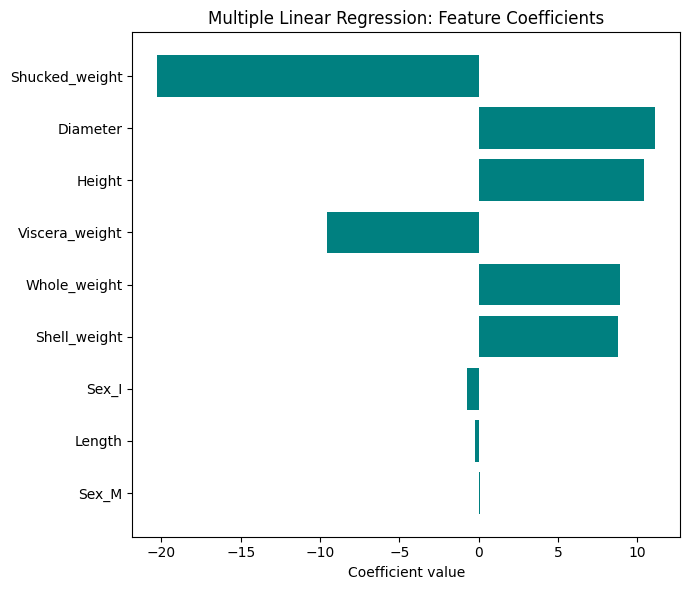

In [ ]:
plt.figure(figsize=(7, 6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color="teal")
plt.xlabel("Coefficient value")
plt.title("Multiple Linear Regression: Feature Coefficients")
plt.tight_layout()
plt.savefig("images/03_multiple_regression_coefficients.png", bbox_inches="tight")
plt.show()

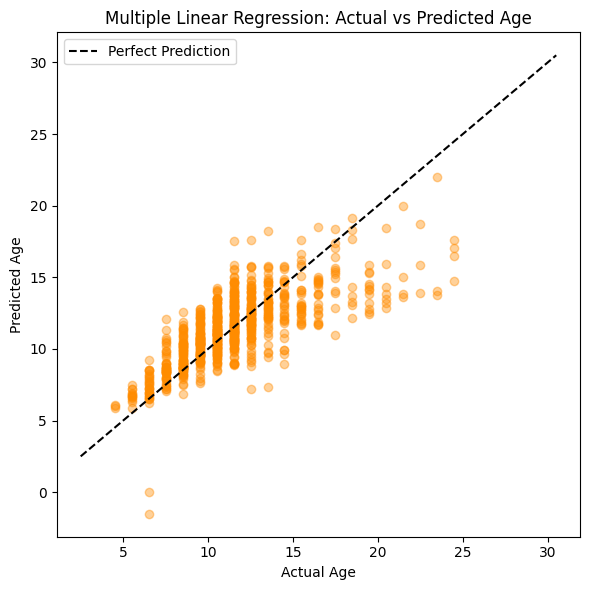

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_m, y_pred_test_m, alpha=0.4, color="darkorange")
lims = [y.min(), y.max()]
plt.plot(lims, lims, color="black", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Multiple Linear Regression: Actual vs Predicted Age")
plt.legend()
plt.tight_layout()
plt.savefig("images/04_multiple_regression_actual_vs_pred.png", bbox_inches="tight")
plt.show()

## 1.3 PCA + Regression (ลดมิติของข้อมูล)
ใช้ Principal Component Analysis (PCA) ลดจำนวน feature ทางกายภาพทั้ง 7 ตัว ให้เหลือเฉพาะ component ที่อธิบายความแปรปรวนได้มากที่สุด แล้วสร้างแบบจำลอง Regression บน component เหล่านั้น

/tmp/ipykernel_534/1969996344.py:17: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/1969996344.py:17: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/1969996344.py:17: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/1969996344.py:17: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/1969996344.py:18: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.savefig("images/05_pca_explained_variance.png", bbox_inches="tight")
/tmp/ipykernel_534/1969996344.py:18: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.savefig("images/05_pca_explained_variance.png", bbox_inches="tight")
/tmp/ipykernel_534/196

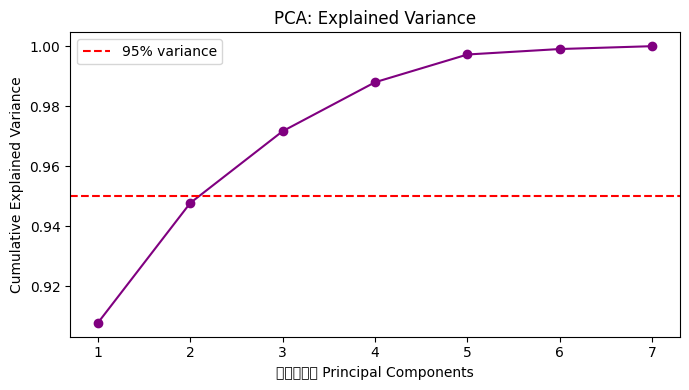

จำนวน Components ที่อธิบายความแปรปรวนได้ >= 95%: 3


In [ ]:
numeric_feats = ["Length","Diameter","Height","Whole_weight",
                  "Shucked_weight","Viscera_weight","Shell_weight"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_feats])

pca_full = PCA().fit(X_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(explained)+1), explained, marker="o", color="purple")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("จำนวน Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Explained Variance")
plt.legend()
plt.tight_layout()
plt.savefig("images/05_pca_explained_variance.png", bbox_inches="tight")
plt.show()

n_components = np.argmax(explained >= 0.95) + 1
print(f"จำนวน Components ที่อธิบายความแปรปรวนได้ >= 95%: {n_components}")

In [ ]:
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pca, df["Age"], test_size=0.2, random_state=RANDOM_STATE
)

pca_lr = LinearRegression()
pca_lr.fit(X_train_p, y_train_p)
y_pred_test_p = pca_lr.predict(X_test_p)

print(f"PCA + Linear Regression -> Test R2: {r2_score(y_test_p, y_pred_test_p):.4f}, "
      f"RMSE: {np.sqrt(mean_squared_error(y_test_p, y_pred_test_p)):.4f}")

PCA + Linear Regression -> Test R2: 0.3928, RMSE: 2.5638


## 1.4 สรุปผล Age Prediction (LAB 1)
เปรียบเทียบ Simple vs Multiple vs PCA-based Linear Regression แบบละเอียดใน LAB 3 ด้านล่าง

---
# LAB 2: Classification (ทำนายเพศ)

## 2.1 Preparing Classification Data
ทำนาย **เพศ (Gender)** ของหอยเป๋าฮื้อ: ใช้เฉพาะกลุ่ม Male (M) และ Female (F) เท่านั้น (ตัด Infant ออกเพราะยังไม่โตเต็มวัย ไม่สามารถระบุเพศทางชีววิทยาได้) -> ทำให้โจทย์นี้กลายเป็น **Binary Classification**

In [ ]:
df_clf = df[df["Sex"].isin(["M", "F"])].copy()
le = LabelEncoder()
df_clf["Gender"] = le.fit_transform(df_clf["Sex"])  # F=0, M=1
print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print(df_clf["Gender"].value_counts())

feature_cols_clf = ["Length","Diameter","Height","Whole_weight",
                     "Shucked_weight","Viscera_weight","Shell_weight"]
X_clf = df_clf[feature_cols_clf]
y_clf = df_clf["Gender"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_c_scaled = scaler_clf.fit_transform(X_train_c)
X_test_c_scaled = scaler_clf.transform(X_test_c)
print("Training set:", X_train_c.shape, " Testing set:", X_test_c.shape)

Mapping: {'F': np.int64(0), 'M': np.int64(1)}
Gender
1    1528
0    1307
Name: count, dtype: int64
Training set: (2268, 7)  Testing set: (567, 7)


## 2.2 Decision Boundary Visualization
ใช้ 2 feature ที่เกี่ยวข้องกับเพศมากที่สุด (`Shell_weight`, `Diameter`) เพื่อแสดง Decision Boundary แบบ 2 มิติ

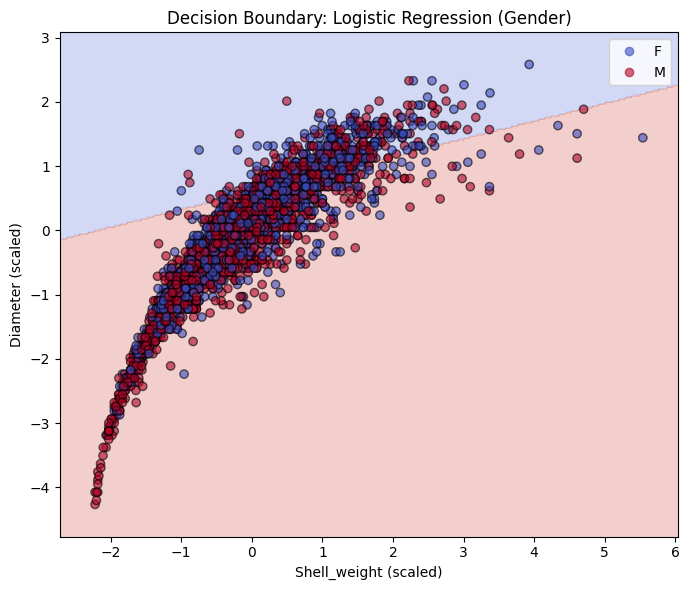

In [ ]:
feat_x, feat_y = "Shell_weight", "Diameter"
X_2d = df_clf[[feat_x, feat_y]].values
y_2d = df_clf["Gender"].values

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

clf_2d = LogisticRegression(random_state=RANDOM_STATE)
clf_2d.fit(X_2d_scaled, y_2d)

xx, yy = np.meshgrid(
    np.linspace(X_2d_scaled[:,0].min()-0.5, X_2d_scaled[:,0].max()+0.5, 300),
    np.linspace(X_2d_scaled[:,1].min()-0.5, X_2d_scaled[:,1].max()+0.5, 300)
)
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
scatter = plt.scatter(X_2d_scaled[:,0], X_2d_scaled[:,1], c=y_2d, cmap="coolwarm", edgecolor="k", alpha=0.6)
plt.xlabel(f"{feat_x} (scaled)")
plt.ylabel(f"{feat_y} (scaled)")
plt.title("Decision Boundary: Logistic Regression (Gender)")
plt.legend(handles=scatter.legend_elements()[0], labels=list(le.classes_))
plt.tight_layout()
plt.savefig("images/06_decision_boundary.png", bbox_inches="tight")
plt.show()

## 2.3 Logistic Regression (ใช้ทุก Feature) และ Gender Prediction

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_c_scaled, y_train_c)

y_pred_c = log_reg.predict(X_test_c_scaled)
y_proba_c = log_reg.predict_proba(X_test_c_scaled)[:, 1]

acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)
auc = roc_auc_score(y_test_c, y_proba_c)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

Accuracy : 0.5309
Precision: 0.5518
Recall   : 0.6961
F1-score : 0.6156
AUC      : 0.5668


In [ ]:
sample_results = pd.DataFrame({
    'Actual': le.inverse_transform(y_test_c.values[:10]),
    'Predicted': le.inverse_transform(y_pred_c[:10]),
    'Probability(M)': np.round(y_proba_c[:10], 3)
})
sample_results

,Actual,Predicted,Probability(M)
0,F,F,0.422
1,M,M,0.705
2,M,M,0.532
3,F,F,0.418
4,F,M,0.591
5,M,F,0.475
6,M,M,0.637
7,F,M,0.505
8,F,F,0.415
9,M,M,0.509


## 2.4 Confusion Matrix

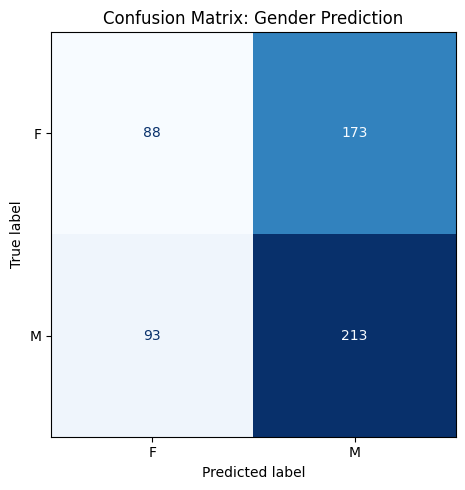

In [ ]:
cm = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix: Gender Prediction")
plt.tight_layout()
plt.savefig("images/07_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 2.5 ROC Curve & AUC

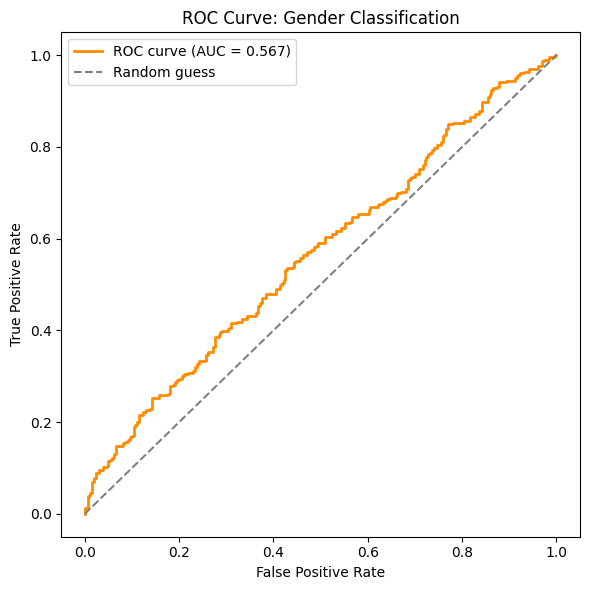

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_c, y_proba_c)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Gender Classification")
plt.legend()
plt.tight_layout()
plt.savefig("images/08_roc_curve.png", bbox_inches="tight")
plt.show()

---
# LAB 3: Model Comparison

## 3.1 Simple vs Multiple Linear Regression

In [ ]:
reg_compare = pd.DataFrame({
    "Model": ["Simple LR (Shell_weight)", "Multiple LR (all features)", "PCA + LR"],
    "Train R2": [
        r2_score(y_train, y_pred_train_s),
        r2_score(y_train_m, y_pred_train_m),
        r2_score(y_train_p, pca_lr.predict(X_train_p)),
    ],
    "Test R2": [
        r2_score(y_test, y_pred_test_s),
        r2_score(y_test_m, y_pred_test_m),
        r2_score(y_test_p, y_pred_test_p),
    ],
    "Test MAE": [
        mean_absolute_error(y_test, y_pred_test_s),
        mean_absolute_error(y_test_m, y_pred_test_m),
        mean_absolute_error(y_test_p, y_pred_test_p),
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_test_s)),
        np.sqrt(mean_squared_error(y_test_m, y_pred_test_m)),
        np.sqrt(mean_squared_error(y_test_p, y_pred_test_p)),
    ],
})
reg_compare

,Model,Train R2,Test R2,Test MAE,Test RMSE
0,Simple LR (Shell_weight),0.391886,0.400853,1.856075,2.546741
1,Multiple LR (all features),0.534824,0.548163,1.593107,2.211613
2,PCA + LR,0.359121,0.392819,1.839579,2.563760


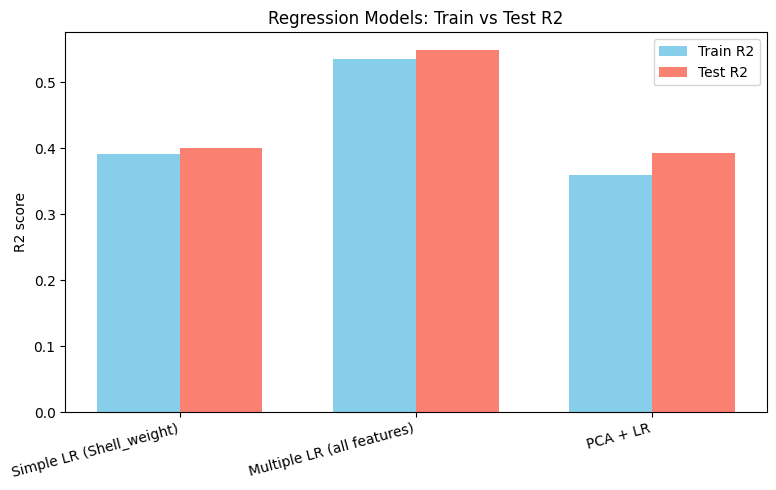

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(reg_compare))
width = 0.35
ax.bar(x - width/2, reg_compare["Train R2"], width, label="Train R2", color="skyblue")
ax.bar(x + width/2, reg_compare["Test R2"], width, label="Test R2", color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(reg_compare["Model"], rotation=15, ha="right")
ax.set_ylabel("R2 score")
ax.set_title("Regression Models: Train vs Test R2")
ax.legend()
plt.tight_layout()
plt.savefig("images/09_regression_comparison.png", bbox_inches="tight")
plt.show()

**สรุป:**
- **Simple Linear Regression** ใช้ feature เดียว ตีความง่าย แต่ประสิทธิภาพจำกัด (R² ต่ำกว่า)
- **Multiple Linear Regression** ใช้หลาย feature ร่วมกัน จับความสัมพันธ์ได้ดีกว่า (R² สูงกว่า) แต่ตีความยากขึ้นและเสี่ยงต่อ multicollinearity
- **PCA + Linear Regression** ลดมิติของข้อมูลก่อนสร้างโมเดล ช่วยลดปัญหา multicollinearity และ overfitting ในกรณีที่มี feature จำนวนมาก ในกรณีนี้ (feature ค่อนข้างน้อยและมีความสัมพันธ์เชิงเส้นชัดเจนอยู่แล้ว) ผลลัพธ์ใกล้เคียงกับ Multiple LR

## 3.2 Training vs Testing Performance

In [ ]:
gap_df = reg_compare.copy()
gap_df["R2 Gap (Train-Test)"] = gap_df["Train R2"] - gap_df["Test R2"]
gap_df[["Model", "Train R2", "Test R2", "R2 Gap (Train-Test)"]]

,Model,Train R2,Test R2,R2 Gap (Train-Test)
0,Simple LR (Shell_weight),0.391886,0.400853,-0.008967
1,Multiple LR (all features),0.534824,0.548163,-0.013338
2,PCA + LR,0.359121,0.392819,-0.033698


> ค่า **R² Gap** ที่น้อย แสดงว่าโมเดล generalize ได้ดี ไม่ overfit กับข้อมูลฝึกสอน หาก Train R² สูงกว่า Test R² มาก แสดงว่าโมเดลจดจำข้อมูลฝึกสอนมากเกินไป (Overfitting)

## 3.3 Regression vs Classification

In [ ]:
task_compare = pd.DataFrame({
    "หัวข้อ": ["ประเภทของผลลัพธ์", "ตัวอย่างเป้าหมาย", "Algorithm ที่ใช้", "ตัวชี้วัดหลัก", "Output ของโมเดล"],
    "Regression (Age Prediction)": [
        "ค่าต่อเนื่อง (Continuous)",
        "อายุ (ปี) เช่น 8.5, 12.3",
        "Linear Regression",
        "R2, MAE, MSE, RMSE",
        "ค่าตัวเลข เช่น 'อายุประมาณ 10.2 ปี'",
    ],
    "Classification (Gender Prediction)": [
        "หมวดหมู่ (Categorical/Discrete)",
        "ตัวผู้ / ตัวเมีย",
        "Logistic Regression",
        "Accuracy, Precision, Recall, F1, AUC",
        "คลาส/ความน่าจะเป็น เช่น 'Male 87%'",
    ],
})
task_compare

,หัวข้อ,Regression (Age Prediction),Classification (Gender Prediction)
0,ประเภทของผลลัพธ์,ค่าต่อเนื่อง (Continuous),หมวดหมู่ (Categorical/Discrete)
1,ตัวอย่างเป้าหมาย,"อายุ (ปี) เช่น 8.5, 12.3",ตัวผู้ / ตัวเมีย
2,Algorithm ที่ใช้,Linear Regression,Logistic Regression
3,ตัวชี้วัดหลัก,"R2, MAE, MSE, RMSE","Accuracy, Precision, Recall, F1, AUC"
4,Output ของโมเดล,ค่าตัวเลข เช่น 'อายุประมาณ 10.2 ปี',คลาส/ความน่าจะเป็น เช่น 'Male 87%'


## 3.4 Model Performance Metrics — สรุปรวม

In [ ]:
clf_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "Score": [acc, prec, rec, f1, auc],
})
print("=== Regression: Age Prediction (Test set) ===")
display(reg_compare)

print()
print("=== Classification: Gender Prediction (Test set) ===")
display(clf_metrics)

=== Regression: Age Prediction (Test set) ===


,Model,Train R2,Test R2,Test MAE,Test RMSE
0,Simple LR (Shell_weight),0.391886,0.400853,1.856075,2.546741
1,Multiple LR (all features),0.534824,0.548163,1.593107,2.211613
2,PCA + LR,0.359121,0.392819,1.839579,2.563760



=== Classification: Gender Prediction (Test set) ===


,Metric,Score
0,Accuracy,0.530864
1,Precision,0.551813
2,Recall,0.696078
3,F1-score,0.615607
4,AUC,0.566799


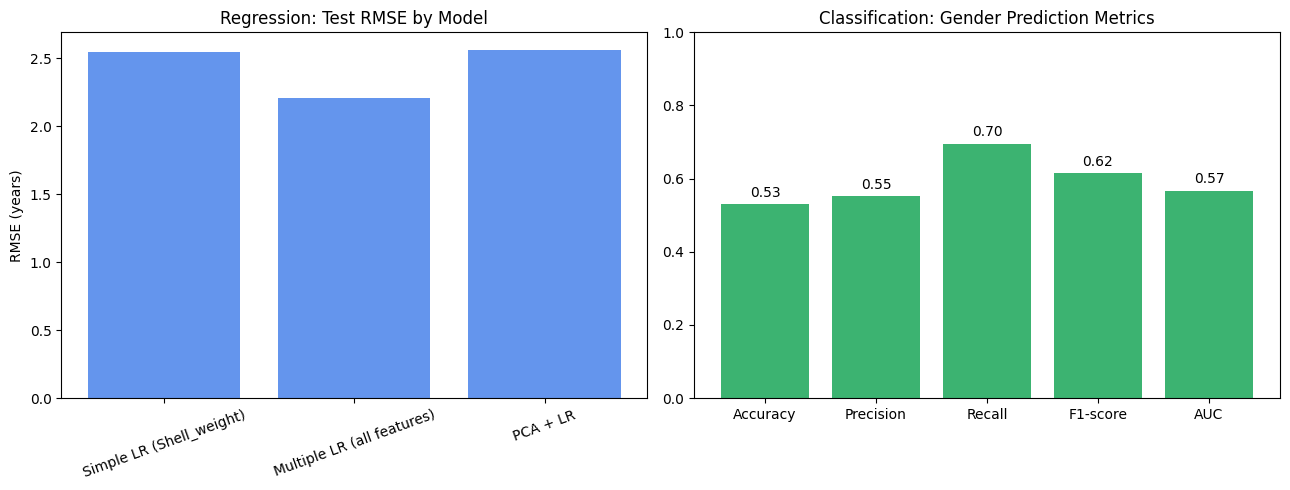

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(reg_compare["Model"], reg_compare["Test RMSE"], color="cornflowerblue")
axes[0].set_title("Regression: Test RMSE by Model")
axes[0].set_ylabel("RMSE (years)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(clf_metrics["Metric"], clf_metrics["Score"], color="mediumseagreen")
axes[1].set_title("Classification: Gender Prediction Metrics")
axes[1].set_ylim(0, 1)
for i, v in enumerate(clf_metrics["Score"]):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.savefig("images/10_final_summary.png", bbox_inches="tight")
plt.show()

---
## สรุป (Conclusion)

1. **Regression** — Multiple Linear Regression ให้ผลดีกว่า Simple Linear Regression อย่างชัดเจน เพราะรวมข้อมูลหลายมิติเข้าด้วยกันในการทำนายอายุ ส่วน PCA ช่วยลดจำนวน feature ลงได้โดยยังรักษาประสิทธิภาพใกล้เคียงกับ Multiple LR
2. **Classification** — Logistic Regression สามารถแยกเพศ (ตัวผู้/ตัวเมีย) ได้ในระดับหนึ่ง แต่ไม่สูงมาก เนื่องจากลักษณะทางกายภาพของตัวผู้และตัวเมียมีความคาบเกี่ยวกันค่อนข้างมาก (ต่างจาก Infant ที่แยกได้ชัดเจนกว่า) — สะท้อนให้เห็นว่าประสิทธิภาพของ Classification ขึ้นอยู่กับว่า feature ที่มีสามารถแยกคลาสได้ดีเพียงใด
3. **Regression vs Classification** — ทั้งสองเป็น Supervised Learning เหมือนกัน ต่างกันที่ประเภทของผลลัพธ์ (ค่าต่อเนื่อง vs หมวดหมู่) และตัวชี้วัดที่ใช้ประเมินผล
4. **Training vs Testing** — การเปรียบเทียบผลบน Train/Test ช่วยตรวจสอบว่าโมเดล overfit หรือไม่ ซึ่งเป็นขั้นตอนสำคัญก่อนนำโมเดลไปใช้งานจริง

---
## References
- Dataset: [Abalone Dataset — Kaggle (rodolfomendes)](https://www.kaggle.com/datasets/rodolfomendes/abalone-dataset)
- Original source: [UCI Machine Learning Repository — Abalone](https://archive.ics.uci.edu/dataset/1/abalone)